In [53]:
!pip install pandas numpy scikit-learn matplotlib seaborn streamlit

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


In [57]:
!pip install requests

import requests

# Download the NSL-KDD training dataset
url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
response = requests.get(url)

with open("KDDTrain+.txt", "wb") as f:
    f.write(response.content)

print(" Dataset downloaded successfully!")

 Dataset downloaded successfully!


In [59]:
# Column names for NSL-KDD dataset
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

# Load dataset
df = pd.read_csv("KDDTrain+.txt", names=columns)

# Preview
print("Shape:", df.shape)
df.head()

Shape: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [61]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [63]:
# See all the different labels (normal vs attacks)
print(df['label'].value_counts())

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


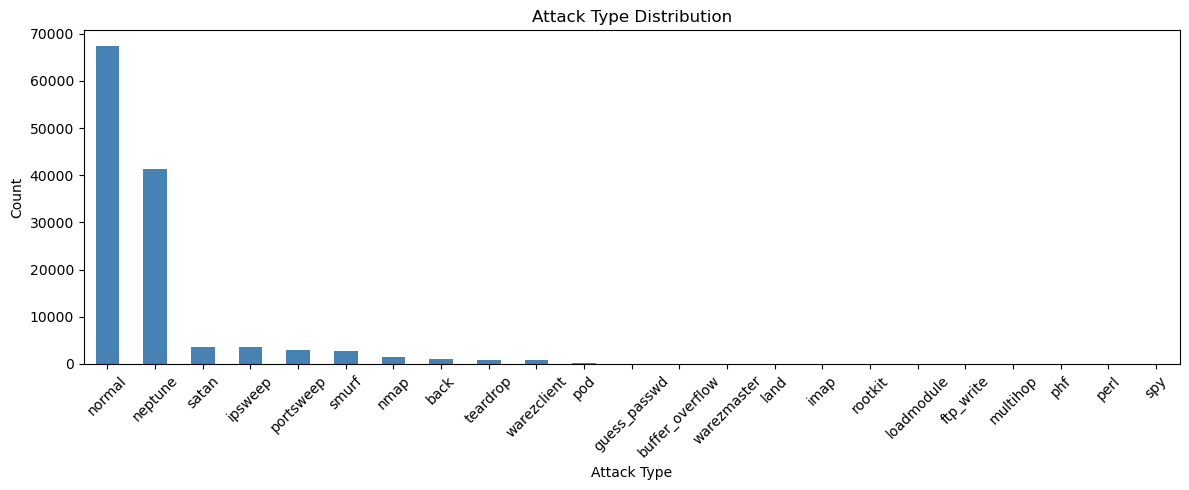

In [65]:
plt.figure(figsize=(12,5))
df['label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Attack Type Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [67]:
# Convert all attack types to just "attack" — binary classification
df['label'] = df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

print(df['label'].value_counts())

label
normal    67343
attack    58630
Name: count, dtype: int64


In [69]:
# Drop the 'difficulty' column as we don't need it
df = df.drop(columns=['difficulty'])

print("Dropped difficulty column")
print("New shape:", df.shape)

Dropped difficulty column
New shape: (125973, 42)


In [71]:
# Machine learning only understands numbers
# So we convert text columns to numbers

le = LabelEncoder()

# These 3 columns are text-based
df['protocol_type'] = le.fit_transform(df['protocol_type'])
df['service'] = le.fit_transform(df['service'])
df['flag'] = le.fit_transform(df['flag'])

print(" Text columns converted to numbers")
df.head()

 Text columns converted to numbers


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack
3,0,1,24,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,1,24,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [73]:
# X = input features (what the model learns from)
# y = output label (normal or attack)

X = df.drop(columns=['label'])
y = df['label']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("\nLabel counts:\n", y.value_counts())

Features shape: (125973, 41)
Labels shape: (125973,)

Label counts:
 label
normal    67343
attack    58630
Name: count, dtype: int64


In [75]:
# 80% data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Data split successfully!
Training samples: 100778
Testing samples: 25195


In [77]:
# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Test the model
dt_predictions = dt_model.predict(X_test)

print(" Decision Tree trained!")
print("\n--- Decision Tree Results ---")
print(classification_report(y_test, dt_predictions))

 Decision Tree trained!

--- Decision Tree Results ---
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11773
      normal       1.00      1.00      1.00     13422

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [79]:
# Train Random Forest model (stronger than Decision Tree)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Test the model
rf_predictions = rf_model.predict(X_test)

print(" Random Forest trained!")
print("\n--- Random Forest Results ---")
print(classification_report(y_test, rf_predictions))

 Random Forest trained!

--- Random Forest Results ---
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11773
      normal       1.00      1.00      1.00     13422

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



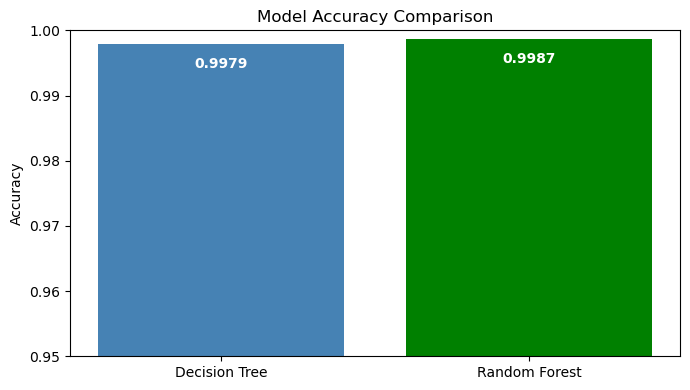


Decision Tree Accuracy: 99.79%
Random Forest Accuracy: 99.87%


In [81]:
from sklearn.metrics import accuracy_score

dt_acc = accuracy_score(y_test, dt_predictions)
rf_acc = accuracy_score(y_test, rf_predictions)

# Plot comparison
models = ['Decision Tree', 'Random Forest']
accuracies = [dt_acc, rf_acc]

plt.figure(figsize=(7,4))
bars = plt.bar(models, accuracies, color=['steelblue', 'green'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.95, 1.0)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.002,
             f'{acc:.4f}', ha='center', va='top', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nDecision Tree Accuracy: {dt_acc*100:.2f}%")
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

In [83]:
# Isolation Forest detects unusual/unknown patterns
# It doesn't need labels — it learns what "normal" looks like

iso_forest = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)
iso_forest.fit(X_train)

print(" Isolation Forest trained!")

 Isolation Forest trained!


In [85]:
# Isolation Forest returns: 1 = normal, -1 = anomaly
iso_predictions = iso_forest.predict(X_test)

# Convert to readable labels
iso_labels = ['normal' if x == 1 else 'anomaly' for x in iso_predictions]

# Count results
import collections
counts = collections.Counter(iso_labels)
print("Anomaly Detection Results:")
print(f"  Normal traffic:    {counts['normal']}")
print(f"  Anomalies detected: {counts['anomaly']}")

Anomaly Detection Results:
  Normal traffic:    22635
  Anomalies detected: 2560


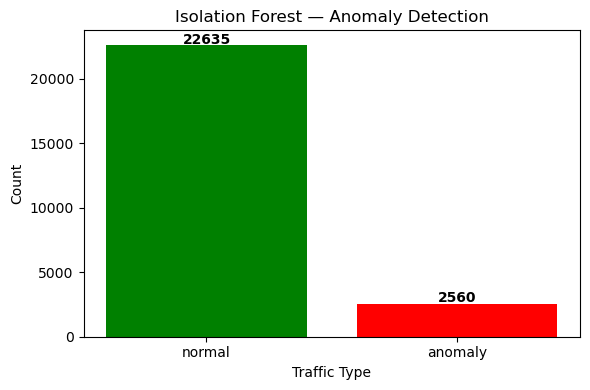

In [87]:
plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color=['green', 'red'])
plt.title('Isolation Forest — Anomaly Detection')
plt.xlabel('Traffic Type')
plt.ylabel('Count')

for i, (label, count) in enumerate(counts.items()):
    plt.text(i, count + 100, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [89]:
# See how well anomaly detection aligns with real labels
y_test_binary = ['normal' if x == 'normal' else 'anomaly' for x in y_test]

correct = sum(1 for a, b in zip(iso_labels, y_test_binary) if a == b)
total = len(iso_labels)

print(f"Isolation Forest Alignment: {correct/total*100:.2f}%")
print("\nNote: Isolation Forest is unsupervised — it never saw the labels!")
print("It detected anomalies purely by learning normal traffic patterns. 🔍")

Isolation Forest Alignment: 56.60%

Note: Isolation Forest is unsupervised — it never saw the labels!
It detected anomalies purely by learning normal traffic patterns. 🔍


/var/folders/qx/_n2h6w0x0yv74_j4dndm634m0000gp/T/ipykernel_58113/3993212450.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')


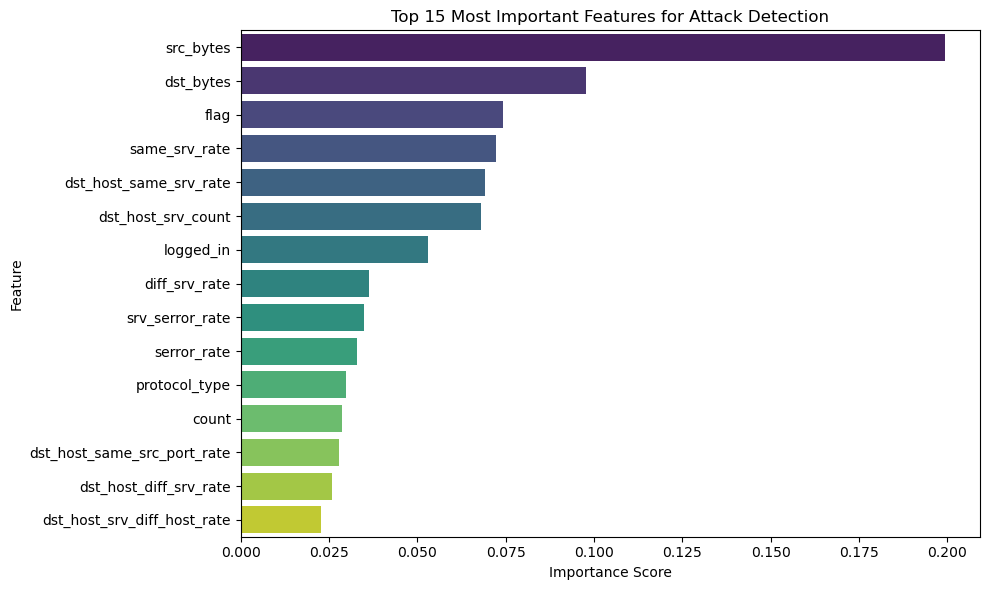

Top 5 most important features:
                   feature  importance
4                src_bytes    0.199256
5                dst_bytes    0.097741
3                     flag    0.074278
28           same_srv_rate    0.072374
33  dst_host_same_srv_rate    0.069044


In [91]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Top 15 Most Important Features for Attack Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feature_importance.head())

In [93]:
import joblib

# Save models so we can use them in the dashboard
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(iso_forest, 'iso_forest.pkl')

print(" Models saved successfully!")
print("📁 rf_model.pkl")
print("📁 iso_forest.pkl")

 Models saved successfully!
📁 rf_model.pkl
📁 iso_forest.pkl


/var/folders/qx/_n2h6w0x0yv74_j4dndm634m0000gp/T/ipykernel_58113/1530643334.py:89: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
/var/folders/qx/_n2h6w0x0yv74_j4dndm634m0000gp/T/ipykernel_58113/1530643334.py:89: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from current font.
  plt.tight_layout()
/Applications/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Applications/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


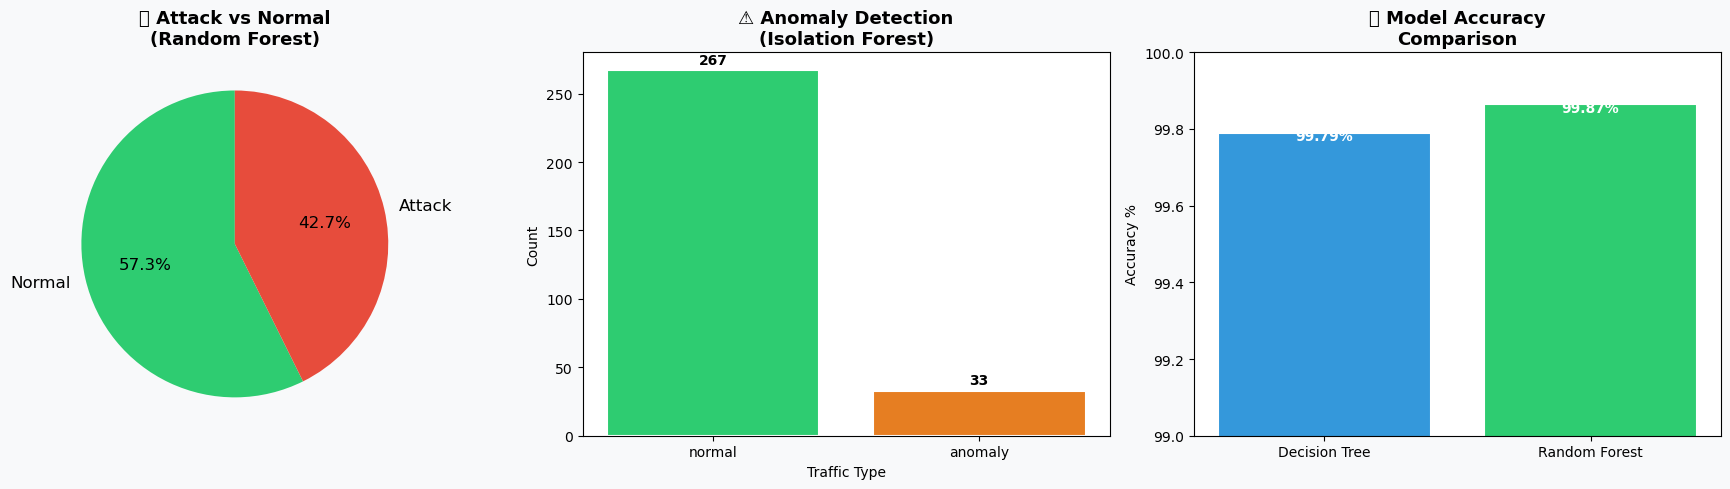

/var/folders/qx/_n2h6w0x0yv74_j4dndm634m0000gp/T/ipykernel_58113/1530643334.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance,
/var/folders/qx/_n2h6w0x0yv74_j4dndm634m0000gp/T/ipykernel_58113/1530643334.py:106: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/Applications/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


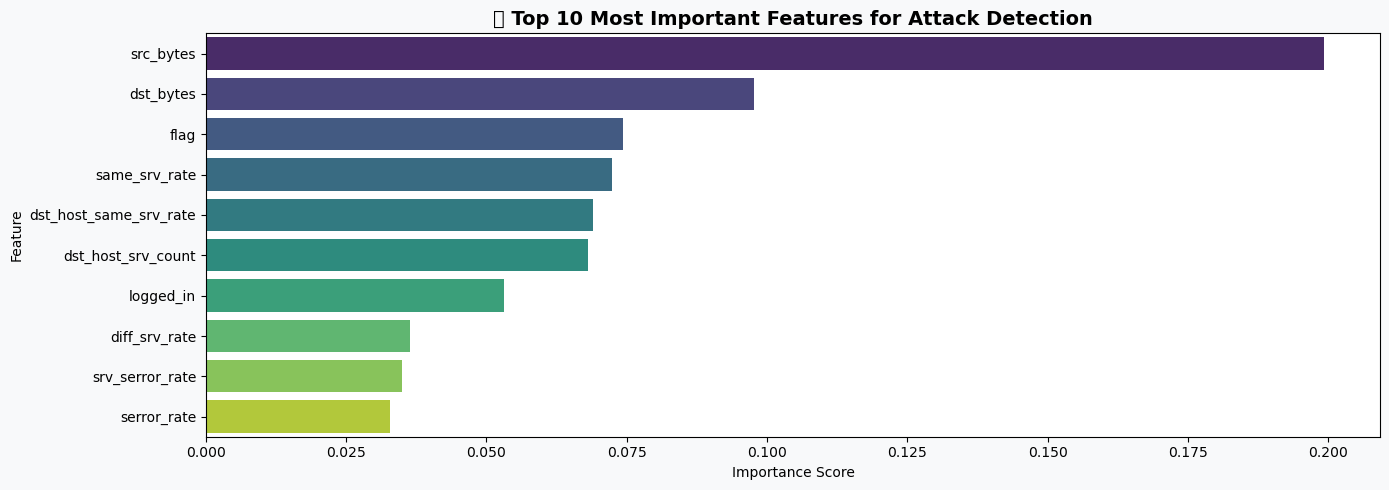

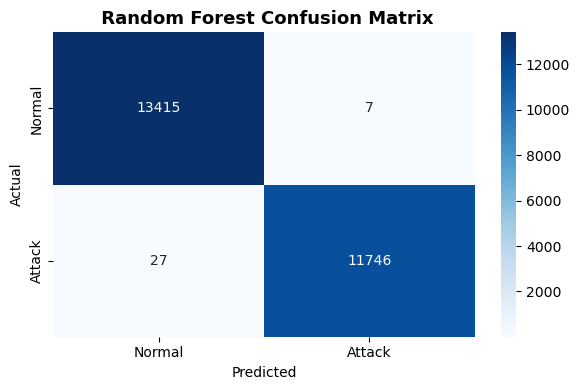

,src_bytes,dst_bytes,flag,protocol_type,duration,RF Prediction,Anomaly,Actual
378,36,0,9,2,0,normal,normal,normal
32038,0,0,5,1,0,attack,normal,attack
86399,0,0,5,1,0,attack,normal,attack
74412,0,0,1,1,0,attack,normal,attack
52951,0,0,4,1,0,attack,anomaly,attack
62143,325,4673,9,1,0,normal,normal,normal
21449,0,0,5,1,0,attack,normal,attack
120009,0,0,1,1,0,attack,normal,attack
34191,0,0,1,1,0,attack,normal,attack
66591,743,335,9,1,0,normal,normal,normal


In [96]:
from IPython.display import display, HTML
import ipywidgets as widgets
from sklearn.metrics import accuracy_score

# ---- HEADER ----
display(HTML("""
<div style='background-color:#1a1a2e; padding:20px; border-radius:10px; margin-bottom:20px'>
    <h1 style='color:#00d4ff; text-align:center'>🛡️ Real-Time AI-Powered Network Monitoring System</h1>
    <p style='color:white; text-align:center'>Group 14 | Semester Project</p>
</div>
"""))

# ---- SAMPLE DATA ----
sample = df.sample(300, random_state=42)
X_sample = sample.drop(columns=['label'])
y_sample = sample['label']

rf_preds = rf_model.predict(X_sample)
iso_preds = iso_forest.predict(X_sample)
iso_labels = ['normal' if x == 1 else 'anomaly' for x in iso_preds]

total = len(rf_preds)
attacks = sum(1 for x in rf_preds if x == 'attack')
normals = total - attacks
anomalies = sum(1 for x in iso_labels if x == 'anomaly')
accuracy = accuracy_score(y_sample, rf_preds)

# ---- METRICS ROW ----
display(HTML(f"""
<div style='display:flex; gap:15px; margin-bottom:20px'>
    <div style='background:#2ecc71; padding:20px; border-radius:10px; flex:1; text-align:center'>
        <h2 style='color:white; margin:0'>{total}</h2>
        <p style='color:white; margin:0'>Total Samples</p>
    </div>
    <div style='background:#3498db; padding:20px; border-radius:10px; flex:1; text-align:center'>
        <h2 style='color:white; margin:0'>{normals}</h2>
        <p style='color:white; margin:0'> Normal Traffic</p>
    </div>
    <div style='background:#e74c3c; padding:20px; border-radius:10px; flex:1; text-align:center'>
        <h2 style='color:white; margin:0'>{attacks}</h2>
        <p style='color:white; margin:0'> Attacks Detected</p>
    </div>
    <div style='background:#e67e22; padding:20px; border-radius:10px; flex:1; text-align:center'>
        <h2 style='color:white; margin:0'>{anomalies}</h2>
        <p style='color:white; margin:0'>⚠ Anomalies Found</p>
    </div>
    <div style='background:#9b59b6; padding:20px; border-radius:10px; flex:1; text-align:center'>
        <h2 style='color:white; margin:0'>{accuracy*100:.2f}%</h2>
        <p style='color:white; margin:0'> RF Accuracy</p>
    </div>
</div>
"""))

# ---- CHARTS ROW 1 ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#f8f9fa')

# Chart 1 - Pie chart
axes[0].pie([normals, attacks], labels=['Normal', 'Attack'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('🔍 Attack vs Normal\n(Random Forest)', fontsize=13, fontweight='bold')

# Chart 2 - Anomaly bar chart
anomaly_counts = pd.Series(iso_labels).value_counts()
bars = axes[1].bar(anomaly_counts.index, anomaly_counts.values,
                   color=['#2ecc71', '#e67e22'], edgecolor='white', linewidth=1.5)
axes[1].set_title('⚠ Anomaly Detection\n(Isolation Forest)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Traffic Type')
axes[1].set_ylabel('Count')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

# Chart 3 - Model comparison
model_names = ['Decision Tree', 'Random Forest']
dt_acc = accuracy_score(y_test, dt_predictions)
rf_acc = accuracy_score(y_test, rf_predictions)
accs = [dt_acc * 100, rf_acc * 100]
bars2 = axes[2].bar(model_names, accs, color=['#3498db', '#2ecc71'],
                    edgecolor='white', linewidth=1.5)
axes[2].set_title('🤖 Model Accuracy\nComparison', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Accuracy %')
axes[2].set_ylim(99, 100)
for bar, acc in zip(bars2, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
                 f'{acc:.2f}%', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# ---- CHART ROW 2 - Feature Importance ----
feature_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

fig2, ax = plt.subplots(figsize=(14, 5))
fig2.patch.set_facecolor('#f8f9fa')
sns.barplot(x='importance', y='feature', data=feature_importance,
            palette='viridis', ax=ax)
ax.set_title('📈 Top 10 Most Important Features for Attack Detection',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

# ---- CONFUSION MATRIX ----
fig3, ax2 = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, rf_predictions, labels=['normal', 'attack'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], ax=ax2)
ax2.set_title(' Random Forest Confusion Matrix', fontsize=13, fontweight='bold')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# ---- TRAFFIC LOG TABLE ----
display(HTML("<h3>📋 Sample Traffic Log with Predictions</h3>"))
sample_display = X_sample[['src_bytes','dst_bytes','flag','protocol_type','duration']].copy()
sample_display['RF Prediction'] = rf_preds
sample_display['Anomaly'] = iso_labels
sample_display['Actual'] = y_sample.values
display(sample_display.head(20))

display(HTML("""
<div style='background-color:#1a1a2e; padding:15px; border-radius:10px; margin-top:20px'>
    <p style='color:#00d4ff; text-align:center; margin:0'>
    🛡️ Real-Time AI Network Monitoring System | Group 14</p>
</div>
"""))

In [98]:
display(HTML("""
<div style='background-color:#1a1a2e; padding:25px; border-radius:10px; margin-bottom:20px'>
    <h1 style='color:#00d4ff; text-align:center'>Project Final Summary</h1>
    <p style='color:white; text-align:center'>Real-Time AI-Powered Network Monitoring and Threat Prediction System</p>
</div>
"""))

dt_acc = accuracy_score(y_test, dt_predictions)
rf_acc = accuracy_score(y_test, rf_predictions)
iso_align = sum(1 for a, b in zip(iso_labels, ['normal' if x == 'normal' else 'anomaly' for x in y_test]) if a == b) / len(iso_labels)

display(HTML(f"""
<div style='font-family:Arial; padding:20px; border:2px solid #00d4ff; border-radius:10px'>

    <h2>Model Performance</h2>
    <table style='width:100%; border-collapse:collapse; font-size:15px'>
        <tr style='background:#3498db; color:white'>
            <th style='padding:10px; text-align:left'>Model</th>
            <th style='padding:10px; text-align:left'>Type</th>
            <th style='padding:10px; text-align:left'>Accuracy</th>
            <th style='padding:10px; text-align:left'>Best For</th>
        </tr>
        <tr style='background:#f2f2f2'>
            <td style='padding:10px'>Decision Tree</td>
            <td style='padding:10px'>Supervised</td>
            <td style='padding:10px'><b>{dt_acc*100:.2f}%</b></td>
            <td style='padding:10px'>Fast, interpretable classification</td>
        </tr>
        <tr>
            <td style='padding:10px'>Random Forest</td>
            <td style='padding:10px'>Supervised</td>
            <td style='padding:10px'><b>{rf_acc*100:.2f}%</b></td>
            <td style='padding:10px'>High accuracy attack detection</td>
        </tr>
        <tr style='background:#f2f2f2'>
            <td style='padding:10px'>Isolation Forest</td>
            <td style='padding:10px'>Unsupervised</td>
            <td style='padding:10px'><b>{iso_align*100:.2f}%</b></td>
            <td style='padding:10px'>Zero-day / unknown attack detection</td>
        </tr>
    </table>

    <h2>Key Findings</h2>
    <ul style='font-size:15px; line-height:2'>
        <li>Random Forest achieved the highest accuracy of <b>{rf_acc*100:.2f}%</b></li>
        <li>Top 3 most important features: <b>src_bytes, dst_bytes, flag</b></li>
        <li>Isolation Forest detected <b>{anomalies}</b> anomalies without using any labels</li>
        <li>Dataset used: <b>NSL-KDD</b> with <b>125,973</b> network traffic records</li>
        <li>Training samples: <b>100,778</b> | Testing samples: <b>25,195</b></li>
    </ul>

    <h2>Algorithms Used</h2>
    <ul style='font-size:15px; line-height:2'>
        <li><b>Decision Tree</b> — Rule-based classification</li>
        <li><b>Random Forest</b> — Ensemble of 100 decision trees</li>
        <li><b>Isolation Forest</b> — Unsupervised anomaly detection</li>
    </ul>

    <h2>Tools and Libraries</h2>
    <ul style='font-size:15px; line-height:2'>
        <li>Python, Jupyter Notebook</li>
        <li>Pandas, NumPy, Scikit-learn</li>
        <li>Matplotlib, Seaborn</li>
    </ul>

</div>
"""))

display(HTML("""
<div style='background-color:#2ecc71; padding:15px; border-radius:10px; margin-top:20px; text-align:center'>
    <h2 style='color:white; margin:0'>Project Complete! - Group 14</h2>
</div>
"""))

Model,Type,Accuracy,Best For
Decision Tree,Supervised,99.79%,"Fast, interpretable classification"
Random Forest,Supervised,99.87%,High accuracy attack detection
Isolation Forest,Unsupervised,59.67%,Zero-day / unknown attack detection
